In [1]:
from the_well.data import WellDataModule
import matplotlib.pyplot as plt
import torch
import numpy as np
import glob
import h5py

datamodule = WellDataModule(
    well_base_path = "../data",
    well_dataset_name = "turbulent_radiative_layer_2D",
    batch_size = 8,
)

train_dataloader = datamodule.train_dataloader()

batch = next(iter(train_dataloader))
print("Batch keys:", batch.keys())

/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch keys: dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])


In [2]:
# Inspect Metatdata to understand channels
meta = datamodule.train_dataset.metadata
print("Spatial Resolution:", meta.spatial_resolution)
print("Field Names:", meta.field_names)

input_fields = batch['input_fields']
print(f"Input fields shape: {input_fields.shape}")
# Expected: (Batch, Time, X, Y, Channels)

Spatial Resolution: (128, 384)
Field Names: {0: ['density', 'pressure'], 1: ['velocity_x', 'velocity_y'], 2: []}
Input fields shape: torch.Size([8, 1, 128, 384, 4])


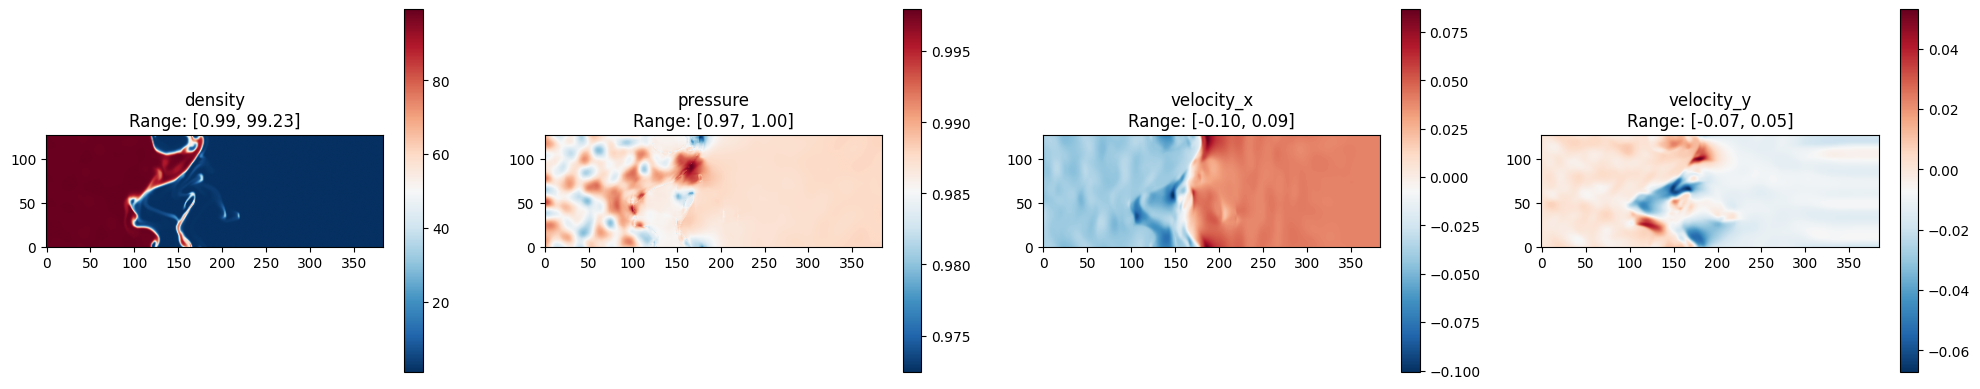

In [3]:
def plot_sample(batch, sample_idx=0, time_idx=0):
    data = batch['input_fields'][sample_idx, time_idx]

    
    n_channels = data.shape[-1]
    fig, axes = plt.subplots(1, n_channels, figsize=(5*n_channels, 4))
    if n_channels == 1: axes = [axes]

    # We need to flatten them in order to match the channel dimension
    all_fields = []
    for i in sorted(meta.field_names.keys()):
        all_fields.extend(meta.field_names[i])
        
    for c in range(n_channels):
        ax = axes[c]
        field_name = all_fields[c] if c < len(all_fields) else f"Channel {c}"
        
        im = ax.imshow(data[..., c], origin='lower', cmap='RdBu_r')
        ax.set_title(f"{field_name}\nRange: [{data[..., c].min():.2f}, {data[..., c].max():.2f}]")
        plt.colorbar(im, ax=ax)
        
    plt.tight_layout()
    plt.show()

plot_sample(batch)

## Manual HDF5 Inspection
Directly inspecting the HDF5 file structure as per user guidance.

Found files: ['../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_0.03.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_0.06.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_0.10.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_0.18.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_0.32.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_0.56.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_1.00.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_1.78.hdf5', '../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_3.16.hdf5']
Inspecting: ../data/turbulent_radiative_layer_2D/data/train/turbulent_radiative_layer_tcool_3.16.hdf5
(8, 101, 128, 384)
<KeysViewHDF5 ['boundary_con

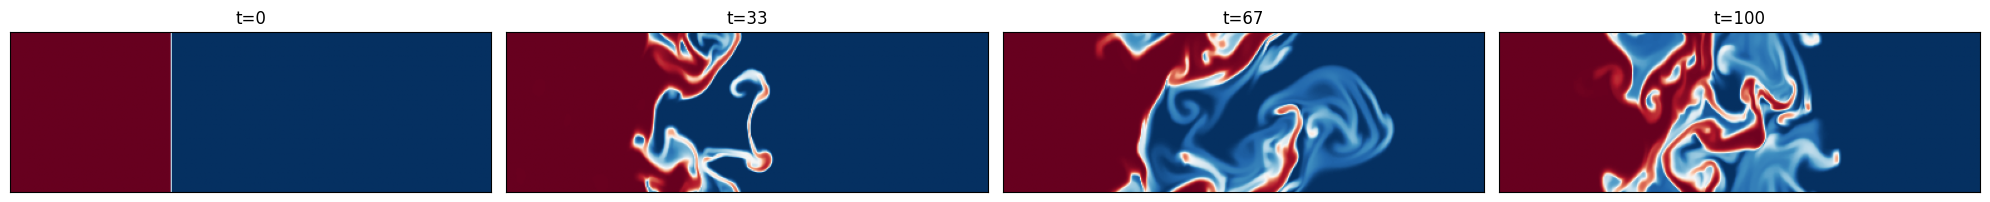

In [ ]:
import glob
import h5py
import matplotlib.pyplot as plt
import numpy as np

set_path = "train"

#Finds all .hdf5 files in the training directory and sorts them
paths = sorted(glob.glob(f"../data/turbulent_radiative_layer_2D/data/{set_path}/*.hdf5"))
print("Found files:", paths)

if paths:
    # select the last path
    p = paths[-1]
    print(f"Inspecting: {p}")

    # print the first layer of keys
    with h5py.File(p, "r") as f: #Open the file in read mode
        if "density" in f["t0_fields"]:
            print(f["t0_fields"]["density"].shape)
        print(f.keys())
        
        print("print bc available:", f["boundary_conditions"].keys())
        if "x_periodic" in f["boundary_conditions"]:
             print("print attributes of the bc:", f["boundary_conditions"]["x_periodic"].attrs.keys())
             print("get the bc type:", f["boundary_conditions"]["x_periodic"].attrs["bc_type"])
        
        #'t0_fields', 't1_fields', 't2_fields' are respectively scalar fields, vector fields and tensor fields
        # print the different fields available in the dataset
        print("t0_fields:", f["t0_fields"].keys())
        print("t1_fields:", f["t1_fields"].keys())
        print("t2_fields:", f["t2_fields"].keys())
        
        # The data is of shape (n_trajectories, n_timesteps, x, y)
        # Get the first t0_field and save it as a numpy array
        if "density" in f["t0_fields"]:
            density = f["t0_fields"]["density"][:]
            print("shape of the selected t0_field: ", density.shape)
            
            traj = 0  # select the trajectory (using 0 as safe default if <4)
            if density.shape[0] > 4:
                traj = 4
            traj_toplot = density[traj]
            
            # field is now of shape (n_timesteps, x, y). Do a subplot to plot it at t= 0, t= T/3, t= 2T/3 and t= T:
            fig, axs = plt.subplots(1, 4, figsize=(20, 5))
            T = traj_toplot.shape[0]
            
            # fix colorbar for all subplots:
            normalize_plots = False
            cmap = "RdBu_r"
            
            if normalize_plots:
                vmin = np.min(traj_toplot)
                vmax = np.max(traj_toplot)
                norm = plt.Normalize(vmin=vmin, vmax=vmax)
                
                for i, t in enumerate([0, T // 3, (2 * T) // 3, T - 1]):
                    axs[i].imshow(traj_toplot[t], cmap=cmap, norm=norm, origin='lower') # origin='lower' is usually safer for physics fields
                    axs[i].set_xticks([])
                    axs[i].set_yticks([])
                    axs[i].set_title(f"t={t}")
            else:
                for i, t in enumerate([0, T // 3, (2 * T) // 3, T - 1]):
                    # Added epsilon to avoid log(0) errors if data has zeros
                    axs[i].imshow(np.log(np.abs(traj_toplot[t]) + 1e-6), cmap=cmap, origin='lower')
                    axs[i].set_xticks([])
                    axs[i].set_yticks([])
                    axs[i].set_title(f"t={t}")
            
            plt.tight_layout()
            plt.savefig("../figures/density_evolution.png")
            plt.show()

            


In [1]:
import the_well

In [2]:
import sys
import os
import logging
import hydra
from omegaconf import OmegaConf
import torch
import wandb

sys.path.append("/home/un212/DiSWellProject/the_well")


from the_well.benchmark.train import train
from the_well.benchmark.utils.experiment_utils import configure_experiment

# 1. Setup Logging
logger = logging.getLogger("the_well")
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())


overrides = [
    "experiment=fno",
    "server=local",
    "data=turbulent_radiative_layer_2D",
    "data.well_base_path=/home/un212/DiSWellProject/My_Masters_Project/data/",
    "data.batch_size=16",
    "data_workers=4",
    "trainer.epochs=1",
    "+data.dataset_kws.train.restrict_num_samples=32", 
    
    # Limit validation to 32 samples
    "+data.dataset_kws.val.restrict_num_samples=32", 
    
    "wandb_project_name=notebook_run"
]

# Path to the config directory inside the package
config_path = "/home/un212/DiSWellProject/the_well/the_well/benchmark/configs"

# 3. Initialize W&B (Disabled for notebook speed)
wandb.init(mode="disabled") 

# 4. Load Config and Run
try:
    with hydra.initialize_config_dir(config_dir=config_path, version_base=None):
        cfg = hydra.compose(config_name="config", overrides=overrides)
        
        cfg, experiment_name, experiment_folder, checkpoint_folder, artifact_folder, viz_folder = configure_experiment(cfg, logger)
        
        print(f"Starting notebook experiment: {experiment_name}")
        
        train(
            cfg,
            experiment_folder,
            checkpoint_folder,
            artifact_folder,
            viz_folder,
            is_distributed=False
        )
        print("Training finished successfully!")
        
except Exception as e:
    print(f"An error occurred: {e}")
    if wandb.run is not None:
        wandb.finish()

/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
Instantiate datamodule the_well.data.WellDataModule


Starting notebook experiment: turbulent_radiative_layer_2D-fno-FNO-0.01


/home/un212/DiSWellProject/the_well/the_well/data/datamodule.py:115: DeprecationWarning: `use_normalization` parameter will be removed in a future version. For proper normalizing, set both use_normalization=True and normalization_type to either ZScoreNormalization or RMSNormalization.Default behavior is `normalization_type=ZScoreNormalization` and `use_normalization=True`.To switch off normalization instead, please set use_normalization=False in the config.yaml file
  warnings.warn(
Instantiate model the_well.benchmark.models.FNO
/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprec

Training finished successfully!


***Tutorial from https://polymathic-ai.org/the_well/tutorials/dataset/***


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from neuralop.models import FNO
from tqdm import tqdm

from the_well.benchmark.metrics import VRMSE
from the_well.data import WellDataset
from the_well.utils.download import well_download

device = "cuda"


In [3]:
base_path = "/home/un212/DiSWellProject/My_Masters_Project/data"

dataset = WellDataset(
    well_base_path=base_path,
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=False,
)

In [4]:
item = dataset[0]

list(item.keys())

['input_fields',
 'output_fields',
 'constant_scalars',
 'boundary_conditions',
 'space_grid',
 'input_time_grid',
 'output_time_grid']

In [8]:
print(item["input_fields"].shape)
print(item["output_fields"].shape)

torch.Size([4, 128, 384, 4])
torch.Size([1, 128, 384, 4])


In [10]:
dataset.metadata.field_names
field_names = [
    name for group in dataset.metadata.field_names.values() for name in group
]
field_names

['density', 'pressure', 'velocity_x', 'velocity_y']

In [20]:


F = dataset.metadata.n_fields

X = dataset[42]["input_fields"]
X = rearrange(X, "T Lx Ly F -> F T Lx Ly")

fig, axs = plt.subplots(F, 4, figsize=(4*2.4, F*1.2), squeeze=False)

for field in range(F):
    vmin = np.nanmin(X[field])
    vmax = np.nanmax(X[field])
    for t in range(4):
        axs[field, t].imshow(X[field, t], cmap = "RdBu_r", interpolation="none", vmin=vmin, vmax=vmax)
        axs[field, t].set_xticks([])
        axs[field, t].set_yticks([])

        axs[0,t].set_title(f"$x_{t}$")

plt.tight_layout()
plt.savefig("../figures/trf2d_input_fields.png", )
plt.show()


In [22]:
model = FNO(
    n_modes=(16, 16),
    in_channels=4 * F,
    out_channels=1 * F,
    hidden_channels=128,
    n_layers=5,
)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

In [25]:
dataset = WellDataset(
    well_base_path="../data",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
)

train_loader = torch.utils.data.DataLoader(
    dataset=dataset,
    shuffle=True,
    batch_size=4,
    num_workers=4,
)

In [27]:
for epoch in range(1):
    for batch in (bar := tqdm(train_loader)):
        x = batch["input_fields"]
        x = rearrange(x, "B Ti Lx Ly F -> B (Ti F) Lx Ly")

        y = batch["output_fields"]
        y = rearrange(y, "B To Lx Ly F -> B (To F) Lx Ly")

        fx = model(x)

        mse = (fx - y).square().mean()
        mse.backward()

        optimizer.step()
        optimizer.zero_grad()

        bar.set_postfix(loss=mse.detach().item())

  0%|          | 0/1746 [00:00<?, ?it/s]/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  return self.__class__(self.tensor[indices])
/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/neuralop/layers/spectral_convolution.py:459: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an

KeyboardInterrupt: 

In [1]:
from the_well.benchmark.models import FNO

model = FNO.from_pretrained("polymathic-ai/FNO-turbulent_radiative_layer_2D")


/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [8]:
import torch
import os
from einops import rearrange
from neuralop.models import FNO
from the_well.benchmark.models import FNO
from the_well.data import WellDataset
from the_well.data.normalization import ZScoreNormalization
from the_well.benchmark.metrics import VRMSE
from tqdm import tqdm
from the_well.benchmark.metrics import NRMSE

# 1. Configuration
DATASET_DIR = "/home/un212/DiSWellProject/My_Masters_Project/data"
DATASET_NAME = "turbulent_radiative_layer_2D"
HF_MODEL_ID = "polymathic-ai/FNO-turbulent_radiative_layer_2D"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load the Test Dataset
test_dataset = WellDataset(
    well_base_path=DATASET_DIR,
    well_dataset_name=DATASET_NAME,
    well_split_name="test",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
    normalization_type=ZScoreNormalization,
)
F = test_dataset.metadata.n_fields

model.eval()

loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)
total_vrmse = 0.0
num_batches = 0

with torch.no_grad():
    for batch in tqdm(loader):
        x = batch["input_fields"].to(device)
        x_input = rearrange(x, "B Ti Lx Ly F -> B (Ti F) Lx Ly")
        y_ref = batch["output_fields"].to(device)
        
        # Inference
        fx = model(x_input)
        fx = rearrange(fx, "B (To F) Lx Ly -> B To Lx Ly F", To=1, F=F)
        
        # Denormalize
        fx_denorm = test_dataset.norm.denormalize_flattened(fx, mode="variable")
        y_denorm = test_dataset.norm.denormalize_flattened(y_ref, mode="variable")
        
        # Metric
        batch_vrmse = NRMSE.eval(fx_denorm, y_denorm, test_dataset.metadata, norm_mode = "std", eps = 1e-3)
        total_vrmse += batch_vrmse.mean().item()
        num_batches += 1

print(f"\nFinal Mean VRMSE on TEST split: {total_vrmse / num_batches:.6f}")


  0%|          | 0/14 [00:00<?, ?it/s]/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  return self.__class__(self.tensor[indices])
/home/un212/DiSWellProject/My_Masters_Project/.venv/lib64/python3.11/site-packages/neuralop/layers/spectral_convolution.py:459: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an e


Final Mean VRMSE on TEST split: 0.934360


  Loaded U-Net: rollout=90 steps, 1-step mean VRMSE=0.1748
  Loaded TFNO: rollout=90 steps, 1-step mean VRMSE=0.2676
  Loaded FNO: rollout=90 steps, 1-step mean VRMSE=0.2825
  Loaded CNext-UNet: rollout=90 steps, 1-step mean VRMSE=0.1204


/tmp/ipykernel_787156/1063385942.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.98])


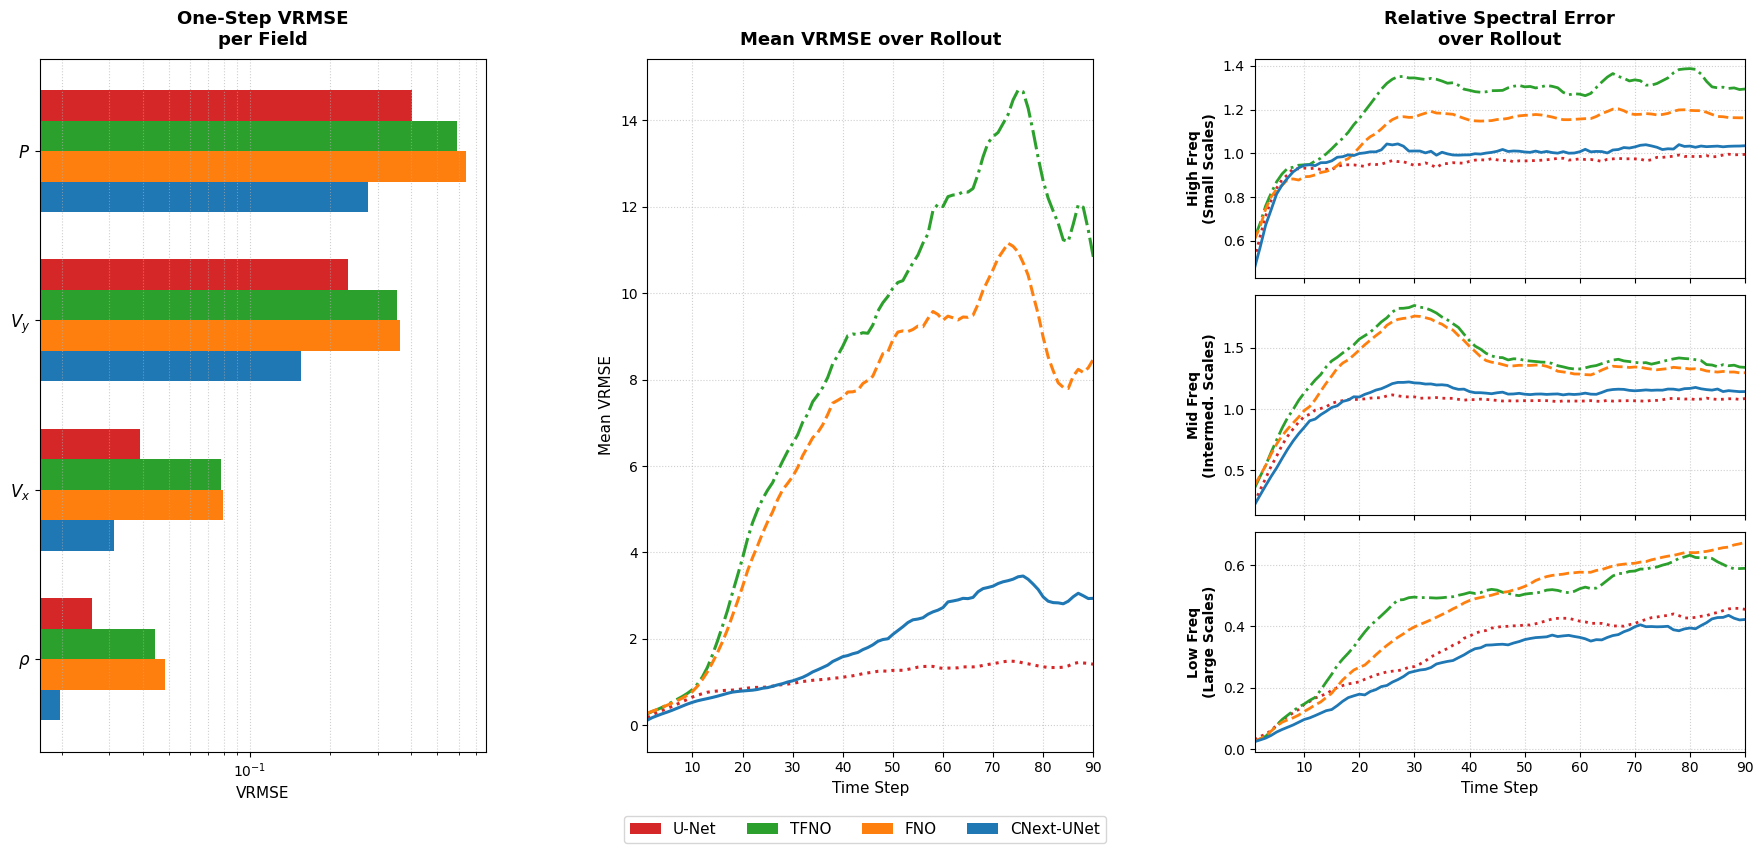


Figure saved to: /home/un212/DiSWellProject/My_Masters_Project/figures/all_models_comparison.png

  Model            1-Step VRMSE   2-Step VRMSE Mean Rollout VRMSE
  U-Net                  0.1748         0.2465             1.0999
  TFNO                   0.2676         0.3224             8.3093
  FNO                    0.2825         0.3259             6.6512
  CNext-UNet             0.1204         0.1800             1.8662


In [7]:
# ==========================================================================
# Model Comparison: FNO vs TFNO vs U-Net vs CNext-UNet
# Run AFTER evaluation jobs have completed and saved results.
# Gracefully skips any models whose .npy files are not yet present.
# ==========================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.gridspec import GridSpec

RESULTS_DIR = "/home/un212/DiSWellProject/My_Masters_Project/results"
FIGURES_DIR  = "/home/un212/DiSWellProject/My_Masters_Project/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Model registry with custom color scheme ────────────────────────────────
models_meta = {
    "U-Net":      ("unet",      "#d62728", ":"),  # Red
    "TFNO":       ("tfno",      "#2ca02c", "-."), # Green
    "FNO":        ("fno",       "#ff7f0e", "--"), # Orange
    "CNext-UNet": ("cnextunet", "#1f77b4", "-"),  # Blue
}

# ── Load results (skip missing) ─────────────────────────────────────────────
mean_vrmse, nrmse = {}, {}
for name, (tag, colour, ls) in models_meta.items():
    v_path = os.path.join(RESULTS_DIR, f"{tag}_vrmse.npy")
    s_path = os.path.join(RESULTS_DIR, f"{tag}_nrmse_spectral.npy")
    if os.path.exists(v_path) and os.path.exists(s_path):
        v = np.load(v_path)   # (T, F)
        s = np.load(s_path)   # (T, 3)
        mean_vrmse[name] = v
        nrmse[name]      = s
        print(f"  Loaded {name}: rollout={v.shape[0]} steps, 1-step mean VRMSE={v[0].mean():.4f}")
    else:
        print(f"  SKIPPING {name}: results not yet available.")

if not mean_vrmse:
    print("\nNo results loaded. Run evaluation jobs first.")
else:
    # Field display order: P, Vy, Vx, rho
    display_names   = ["$P$", "$V_y$", "$V_x$", r"$\rho$"]
    display_indices = [1, 3, 2, 0]
    bin_labels  = ["High Freq\n(Small Scales)", "Mid Freq\n(Intermed. Scales)", "Low Freq\n(Large Scales)"]
    bin_indices = [2, 1, 0]

    colours    = {n: c for n, (_, c, _) in models_meta.items()}
    linestyles = {n: ls for n, (_, _, ls) in models_meta.items()}

    # ── Layout: 3 rows x 3 cols ─────────────────────────────────────────────
    # Col 0: one-step VRMSE bar chart (spans all rows)
    # Col 1: mean rollout VRMSE curve (spans all rows)
    # Col 2: spectral error (3 freq bins, one per row)
    fig = plt.figure(figsize=(22, 9))
    gs  = GridSpec(3, 3, width_ratios=[1, 1, 1.1], figure=fig,
                   hspace=0.08, wspace=0.35)

    # ── LEFT: One-step VRMSE bar chart per field ─────────────────────────────
    ax_bar  = fig.add_subplot(gs[:, 0])
    n_m     = len(mean_vrmse)
    bar_h   = 0.18
    offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * bar_h
    y_idx   = np.arange(len(display_names))

    for offset, (name, (tag, colour, ls)) in zip(offsets, models_meta.items()):
        if name not in mean_vrmse:
            continue
        vals = mean_vrmse[name][0, display_indices]
        ax_bar.barh(y_idx + offset, vals, bar_h, label=name, color=colour)

    ax_bar.set_title("One-Step VRMSE\nper Field", fontsize=13, fontweight="bold", pad=10)
    ax_bar.set_xlabel("VRMSE", fontsize=11)
    ax_bar.set_xscale("log")
    #ax_bar.set_xlim(0.1,10)
    ax_bar.set_yticks(y_idx)
    ax_bar.set_yticklabels(display_names, fontsize=12)
    ax_bar.invert_yaxis()
    ax_bar.grid(True, which="both", axis="x", linestyle=":", alpha=0.6)

    # ── CENTRE: Mean rollout VRMSE curve (averaged over fields) ──────────────
    ax_roll = fig.add_subplot(gs[:, 1])
    ax_roll.set_title("Mean VRMSE over Rollout", fontsize=13, fontweight="bold", pad=10)

    for name in models_meta:
        if name not in mean_vrmse:
            continue
        T     = mean_vrmse[name].shape[0]
        steps = np.arange(1, T + 1)
        # Mean over all fields at each step
        curve = mean_vrmse[name].mean(axis=1)
        ax_roll.plot(steps, curve,
                     color=colours[name], linestyle=linestyles[name],
                     linewidth=2.2, label=name)

    ax_roll.set_xlabel("Time Step", fontsize=11)
    ax_roll.set_ylabel("Mean VRMSE", fontsize=11)
    ax_roll.grid(True, linestyle=":", alpha=0.6)
    max_T = max(v.shape[0] for v in mean_vrmse.values())
    ax_roll.set_xticks(np.arange(0, max_T + 1, 10))
    ax_roll.set_xlim(1, max_T)

    # ── RIGHT: Spectral error by frequency bin ────────────────────────────────
    ax_spectral = []
    for i, b_idx in enumerate(bin_indices):
        ax = fig.add_subplot(gs[i, 2])
        if i == 0:
            ax.set_title("Relative Spectral Error\nover Rollout", fontsize=13, fontweight="bold", pad=10)
        ax_spectral.append(ax)

        for name in models_meta:
            if name not in nrmse:
                continue
            T     = nrmse[name].shape[0]
            steps = np.arange(1, T + 1)
            ax.plot(steps, nrmse[name][:, b_idx],
                    color=colours[name], linestyle=linestyles[name],
                    linewidth=2.0, label=name)

        ax.set_ylabel(bin_labels[i], fontsize=10, fontweight="bold")
        ax.grid(True, linestyle=":", alpha=0.6)
        if i < 2:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel("Time Step", fontsize=11)
            ax.set_xticks(np.arange(0, max_T + 1, 10))
        ax.set_xlim(1, max_T)

    # ── Legend ────────────────────────────────────────────────────────────────
    handles, labels = ax_bar.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=n_m,
               fontsize=11, bbox_to_anchor=(0.5, 0.0))

    missing = [n for n in models_meta if n not in mean_vrmse]
    if missing:
        fig.text(0.5, 0.97, f"Note: {', '.join(missing)} results not yet available",
                 ha="center", fontsize=9, color="gray", style="italic")

    plt.tight_layout(rect=[0, 0.06, 1, 0.98])
    fig_path = os.path.join(FIGURES_DIR, "all_models_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nFigure saved to: {fig_path}")

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print(f"  {'Model':<14} {'1-Step VRMSE':>14} {'2-Step VRMSE':>14} {'Mean Rollout VRMSE':>18}")
    print("="*70)
    for name in models_meta:
        if name in mean_vrmse:
            v1    = mean_vrmse[name][0].mean()
            v2 = mean_vrmse[name][1].mean() if mean_vrmse[name].shape[0] > 1 else float('nan')
            v_all = mean_vrmse[name].mean()
            print(f"  {name:<14} {v1:>14.4f} {v2:>14.4f} {v_all:>18.4f}")
    print("="*70)